# Testing compartment models

This notebook explores and validates the compartment models currently implemented in MicroTorch. Specifically it:

* Identifies all compartment models implemented in MicroTorch.
* Uses the ModelMaker function to create an instance of each compartment model.
* Generate signals using a range of parameter combinations for each model.
* Plot the simulated signals to compare model behaviours and verify correctness.

**Path setup:** First we ensure the project paths are correctly set up so that local modules and data can be accessed from this notebook.

In [1]:
from notebook_setup import add_project_path_to_notebook
add_project_path_to_notebook()

from microtorch.utils.paths import PROJECT_ROOT, SIMULATION_PATH

print("Found project root and path to simulated data at the following locations")
print(f"Project root: {PROJECT_ROOT}")
print(f"Simulation path: {SIMULATION_PATH}")

Found project root and path to simulated data at the following locations
Project root: /Users/paddyslator/python/microtorch/src/microtorch
Simulation path: /Users/paddyslator/python/microtorch/simulation_data


**Import Models**: Next, we import all model compartments currently available in MicroTorch, with the option to exclude specific models if needed.

In [2]:
import microtorch.signal_models as sm

exclude = {'Standard_WM','t1_smdt',"Ballt2"}

compartments = [c for c in sm.__all__ if c not in exclude]

print(f"loaded the following compartments: {compartments}")


loaded the following compartments: ['Ball', 'Msdki', 'Zeppelin', 'Tensor', 'Sphere', 'Dot', 'Stick', 'Astrosticks']


**Create Model Instances**: We use the ModelMaker module to instantiate each compartment model.

In [3]:
import matplotlib.pyplot as plt

from microtorch.model_maker import ModelMaker

modelfunc = {}

for compartment in compartments:            
    
    modelfunc[compartment] = ModelMaker(compartment)

    

No YAML configuration found for Ball model.
Falling back to parsing model name for compartments: ['Ball'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Ball
########### Compartments: ['Ball']
########### Parameter names: [['D']]
########### Parameter ranges: [[[0.001, 3]]]
-----------
No YAML configuration found for Msdki model.
Falling back to parsing model name for compartments: ['Msdki'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Msdki
########### Compartments: ['Msdki']
########### Parameter names: [['D', 'K']]
########### Parameter ranges: [[[0.001, 3], [0.001, 2]]]
-----------
No YAML configuration found for Zeppelin model.
Falling back to parsing model name for compartments: ['Zeppelin'].
Parameter ranges will be the default compartment values.
-----------
########### Making model:  Zeppelin
########### Compartments: ['Zeppelin']
########### Parameter names: [['Dpar', 'k', 't

**Load Acquisition Parameters:**
We load an example gradient table to simulate the signal. Different gradient schemes will be better suited to different compartment models.

In [4]:
from microtorch.utils.acquisition_scheme import acquisition_scheme_loader
import os

grad = acquisition_scheme_loader(os.path.join(SIMULATION_PATH,"grad","grad_HCP_with_deltas.txt"))

Assumed b-values are given in s/mm^2 and converted to ms/μm^2 for internal use. If this is not correct, please check your b-values and ensure they are in the correct units.
Calculated gradient strengths from b-values and timing parameters.
Assuming b-values are in ms/μm^2, delta and Delta are in ms. Gradient strengths will be in mT/μm.


**Sample Parameters and Simulate Signal:**
We sample a set of parameter combinations from the defined ranges for each compartment model, and simulate the corresponding signals. The number of samples can be adjusted via n_samples.

In [5]:
import torch
import matplotlib.pyplot as plt 
from microtorch.utils.make_test_image import generate_random_params

S = {}
n_samples = 5

for compartment in compartments:
    #randomly sample a parameter set from the parameter space of the model.
    params = generate_random_params(modelfunc[compartment], n_samples)

    S[compartment] = modelfunc[compartment](grad, params).unsqueeze(0)



**Plotting the Signals:**
We plot the simulated signals against b-value for each model and parameter combination.

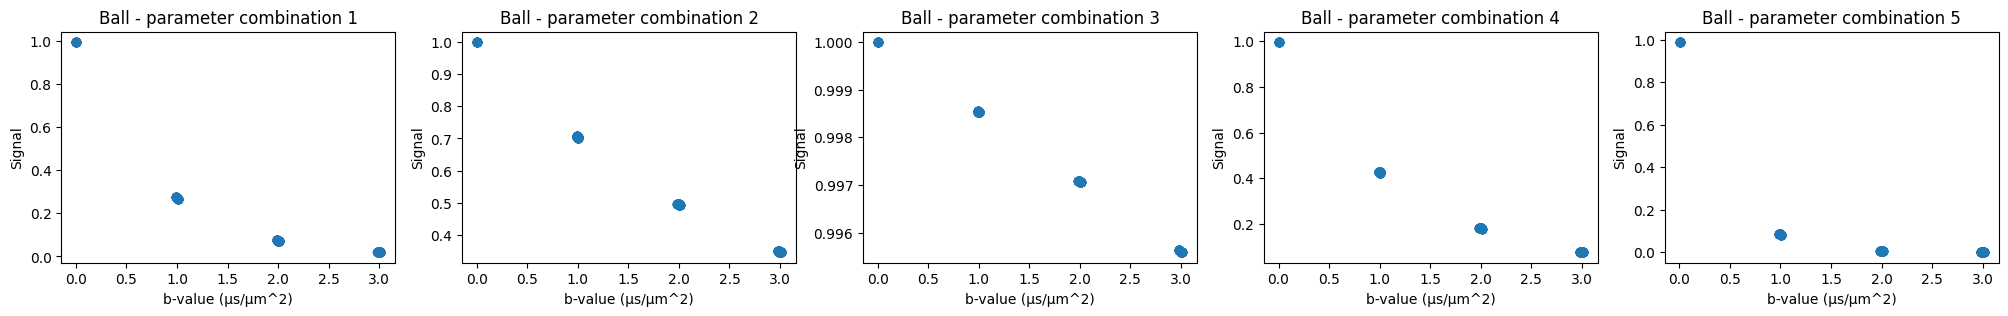

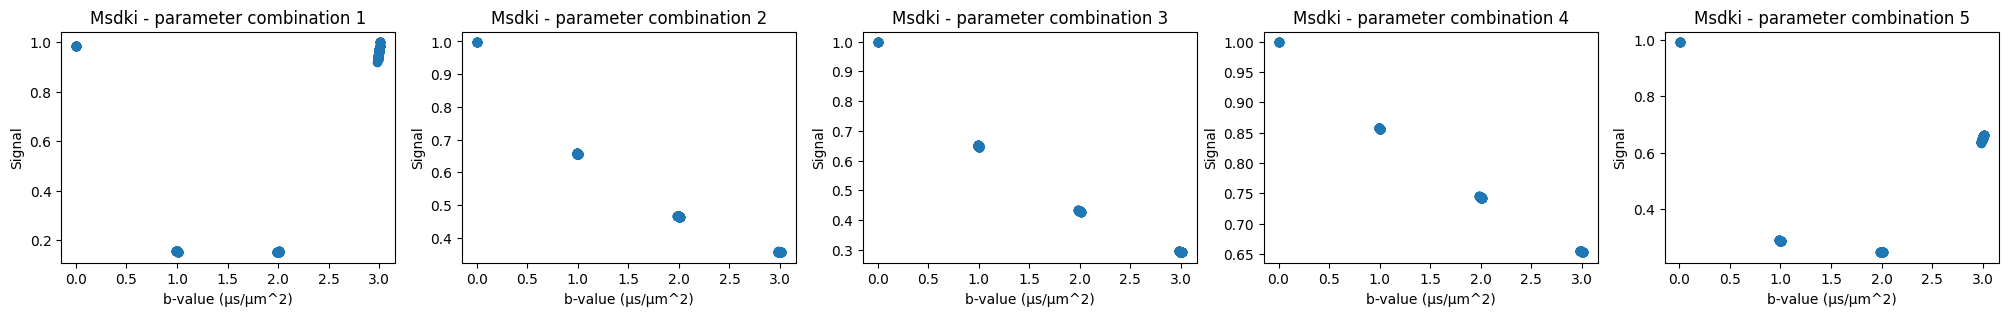

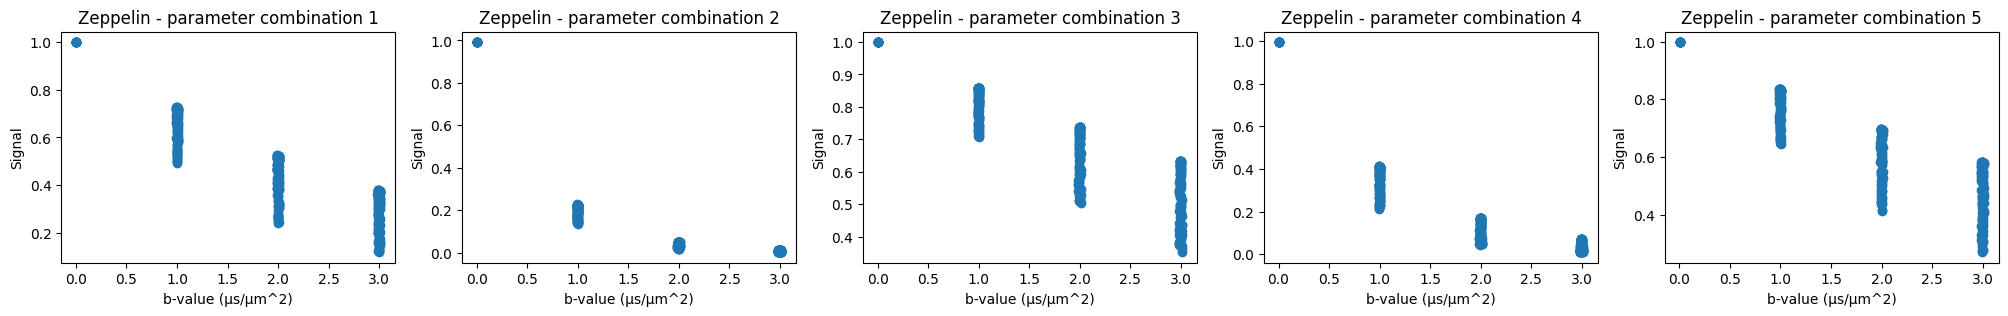

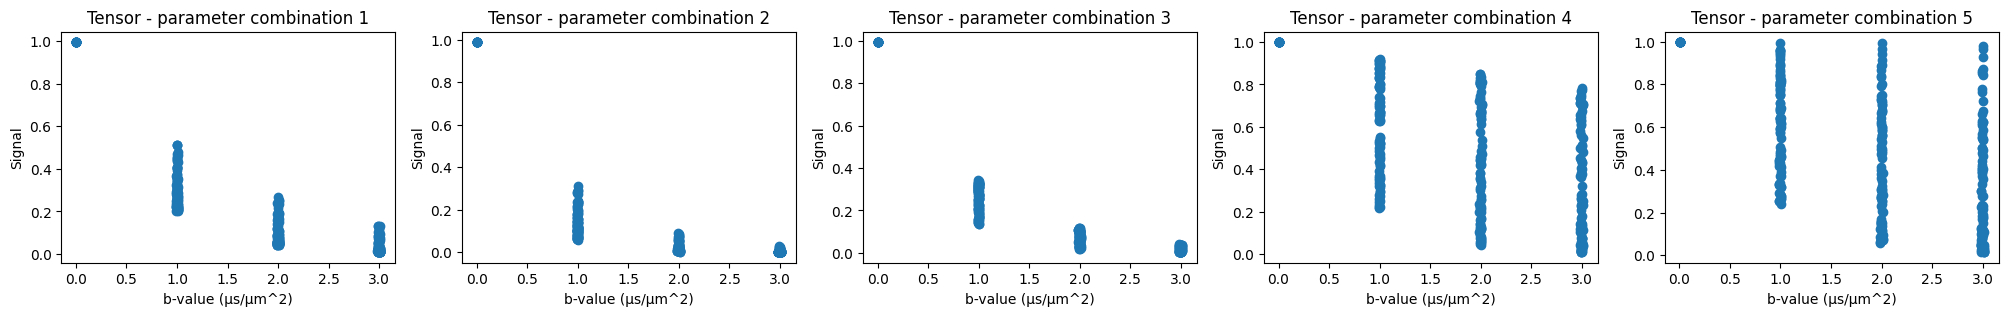

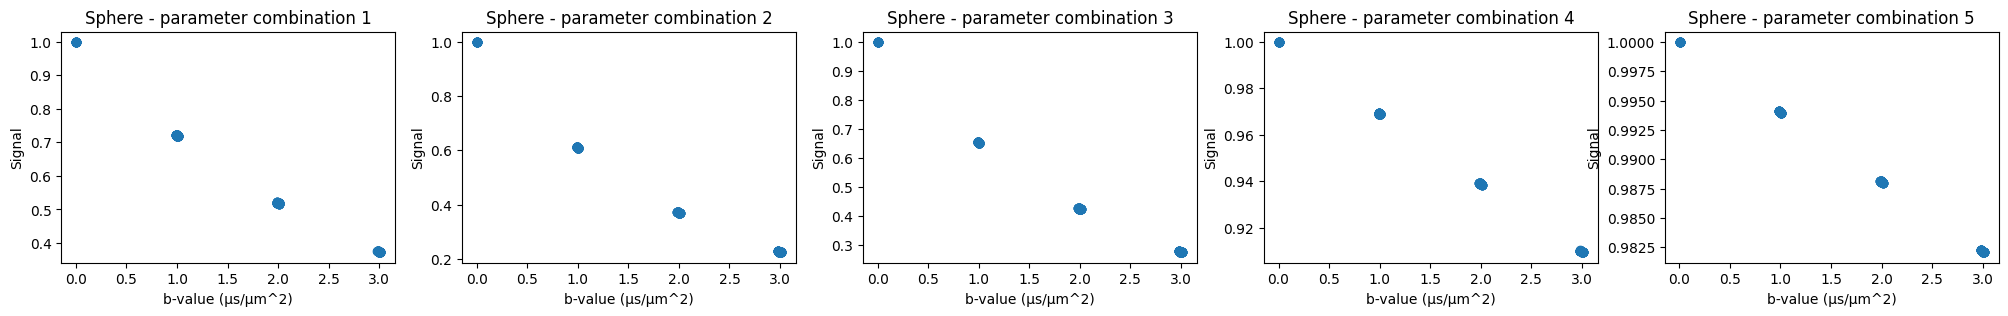

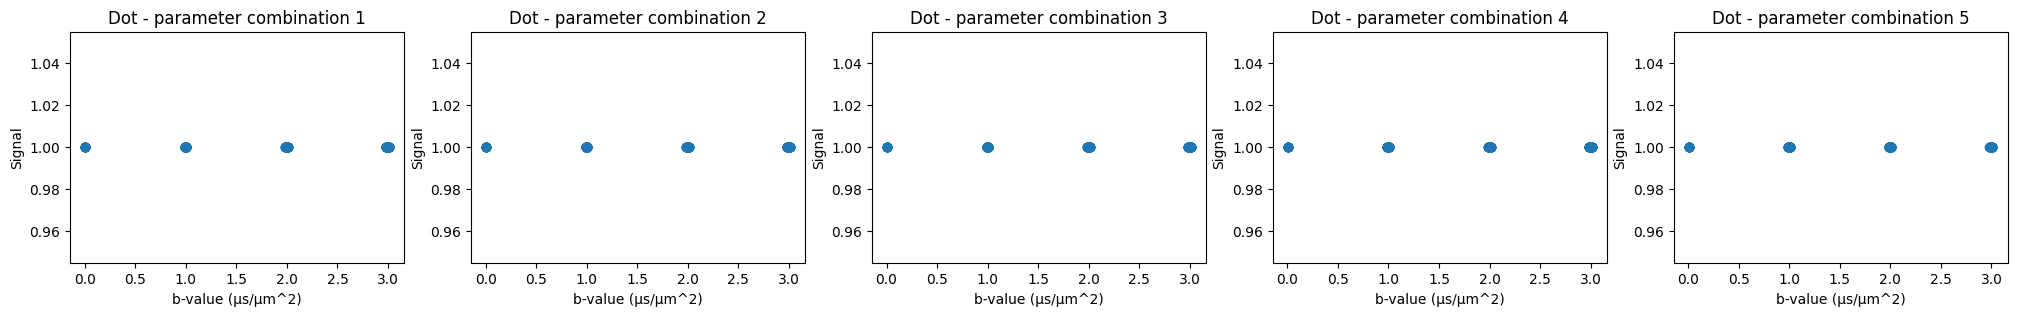

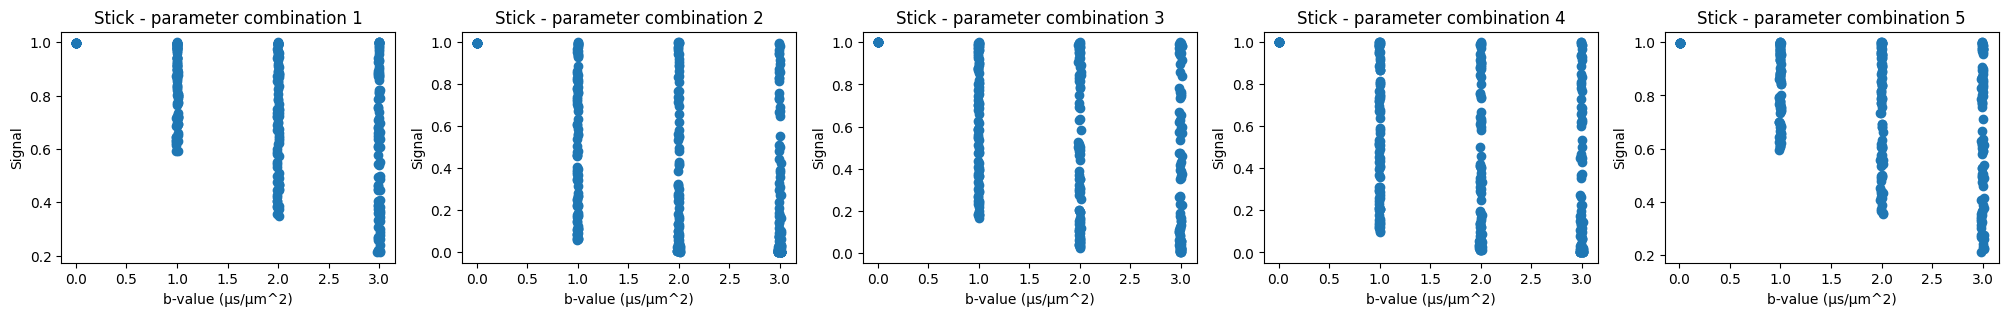

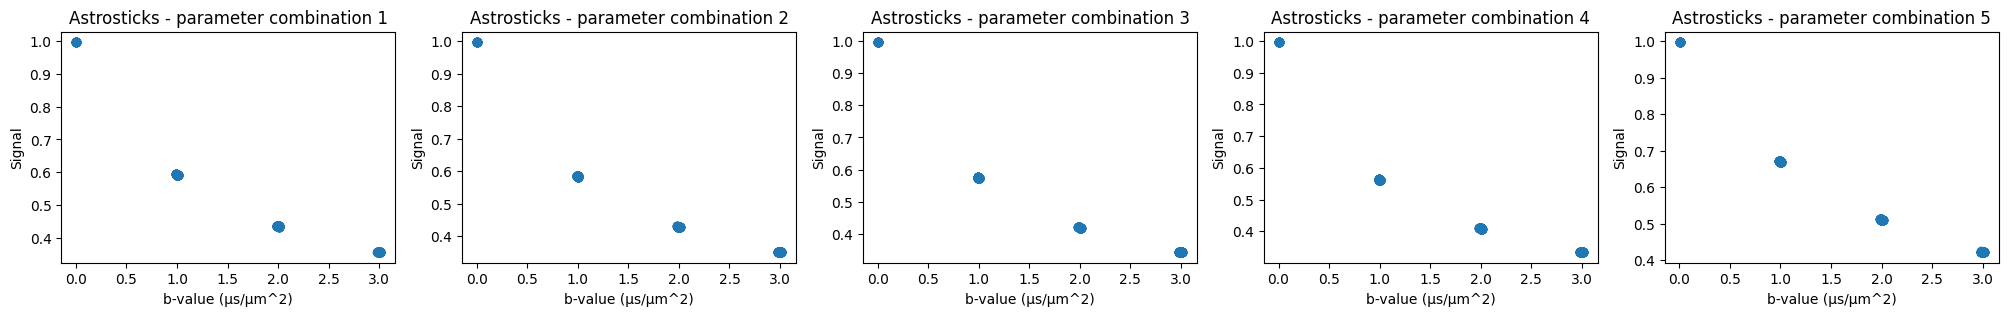

In [6]:
for compartment in compartments:
    n_voxels = S[compartment].shape[1]
    _, ax = plt.subplots(1, n_voxels, figsize=(5 * n_voxels, 3))
    for i in range(n_voxels):
        ax[i].plot(grad.bvalues, S[compartment][0,i,:],'o')
        ax[i].set_title(f"{compartment} - parameter combination {i+1}")

        ax[i].set_xlabel("b-value (μs/μm^2)")
        ax[i].set_ylabel("Signal")

**Plotting the Signals:**
We plot the simulated signals as a time series for each model and parameter combination.

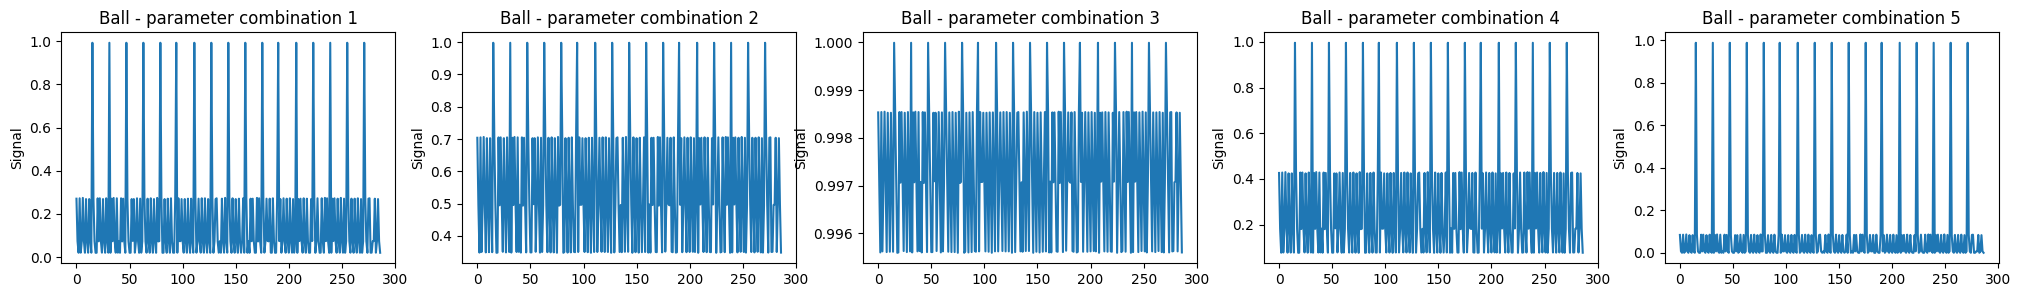

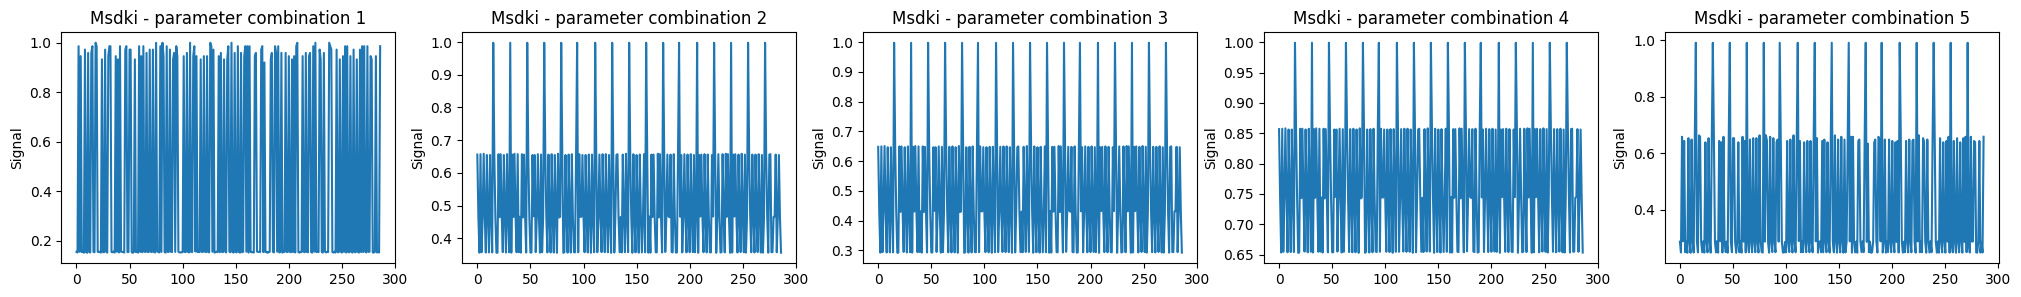

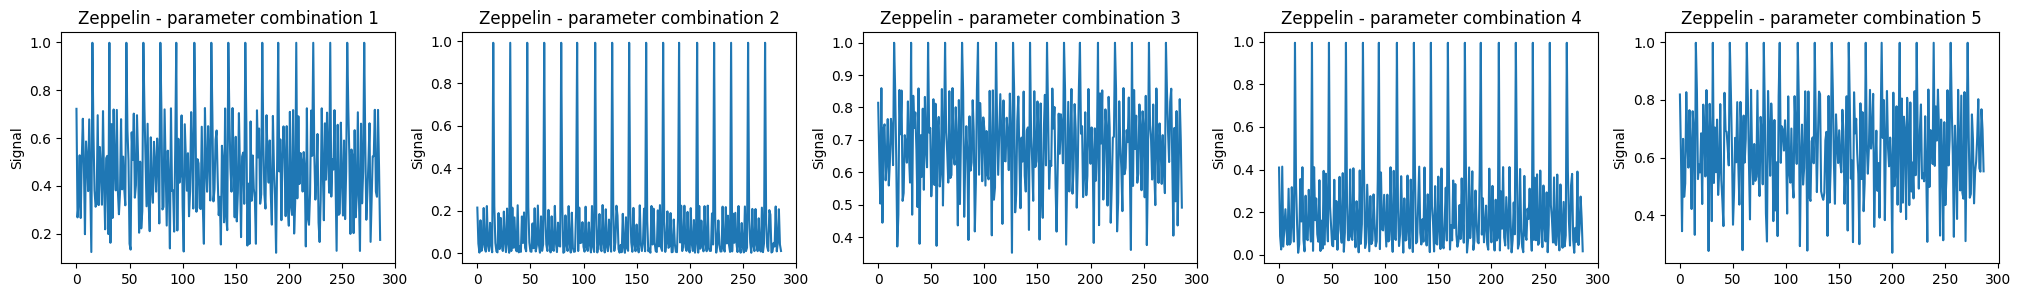

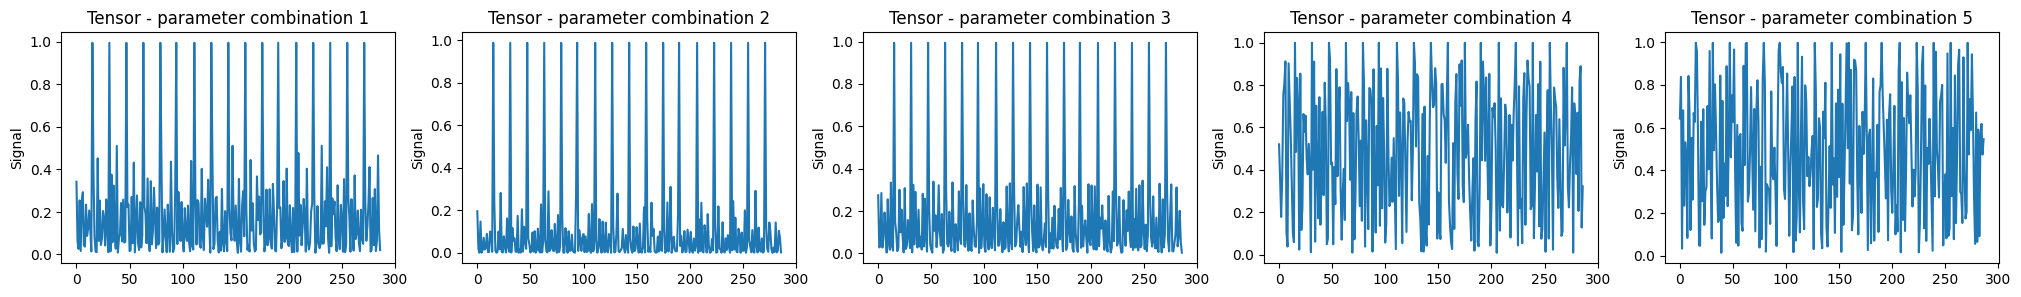

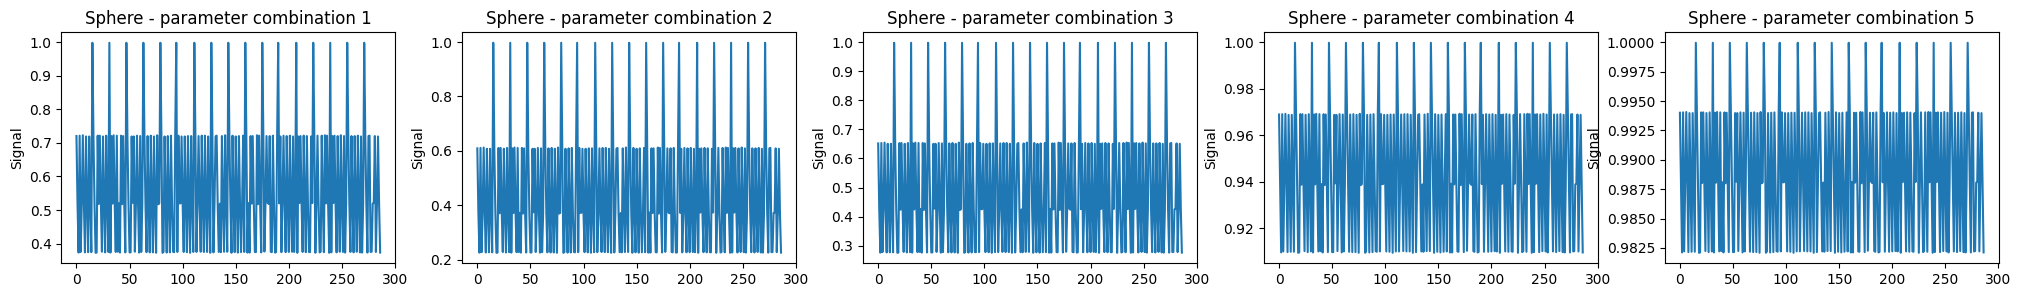

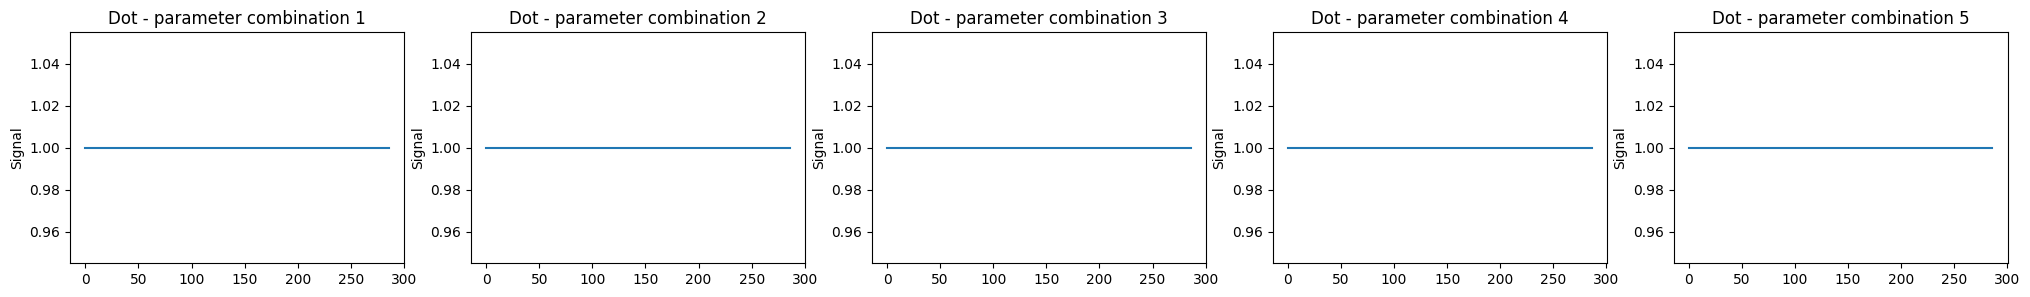

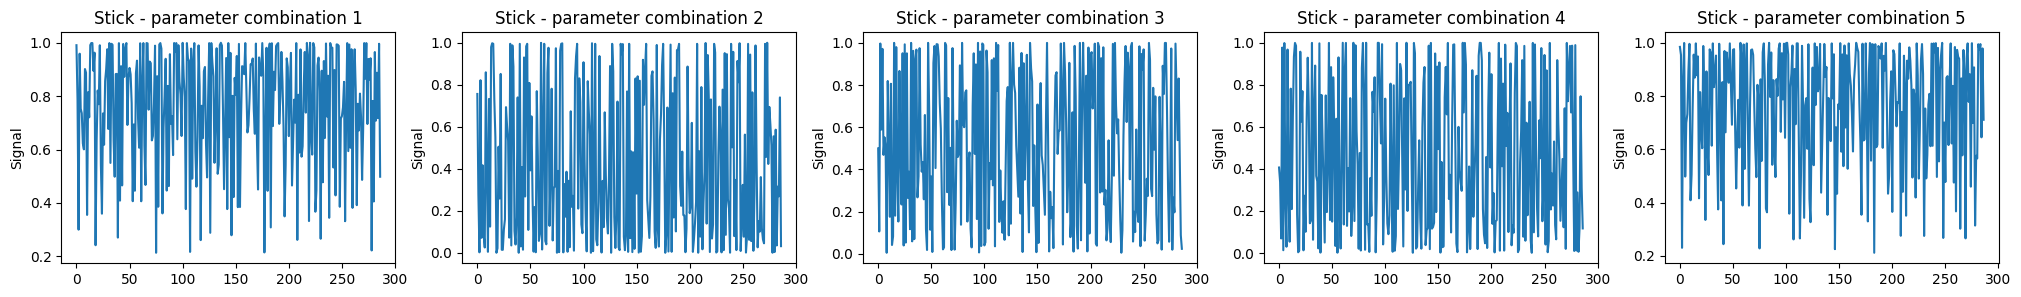

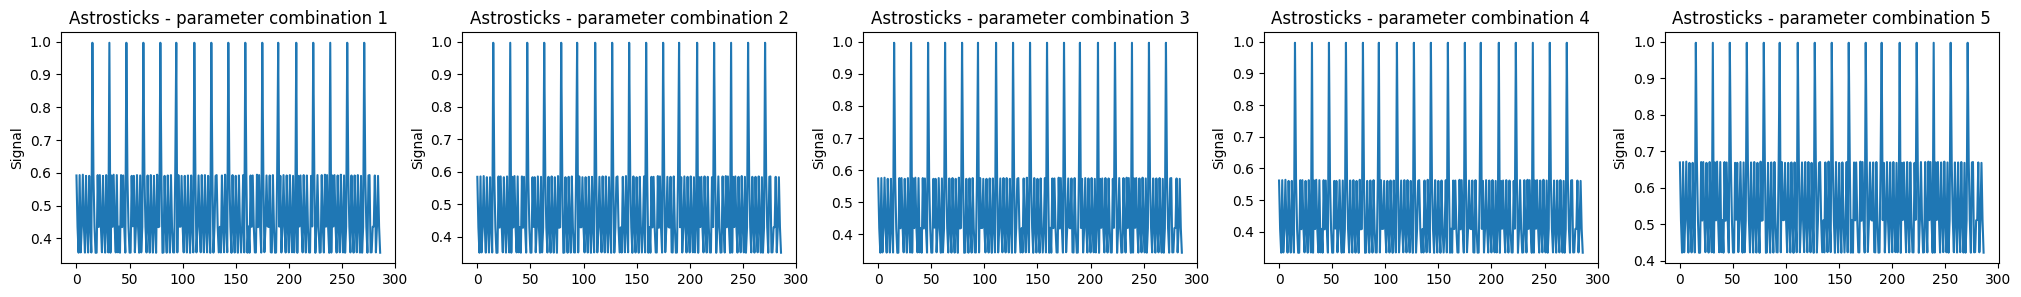

In [7]:
for compartment in compartments:
    n_voxels = S[compartment].shape[1]
    _, ax = plt.subplots(1, n_voxels, figsize=(5 * n_voxels, 3))
    for i in range(n_voxels):
        ax[i].plot(S[compartment][0,i,:])
        ax[i].set_title(f"{compartment} - parameter combination {i+1}")

        ax[i].set_ylabel("Signal")